# FPGA Speaker Recognition — FINN Synthesis with MLP Fully Connected architecture

### Channel strategy

The MFCC dataset has 2 channels (I and Q from IQ radio data).
Both variants support a `USE_CHANNELS` config:
- `'I'` — use only the I channel (safest, matches KWS example)
- `'IQ'` — use both channels (more signal info, slightly higher risk)


---
## 1. Environment Setup

In [1]:
import torch
import numpy as np
import onnx

import os, json, pickle, copy, time, subprocess
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import brevitas.nn as qnn
import brevitas.config as brev_cfg
brev_cfg.IGNORE_MISSING_KEYS = True

from brevitas.quant import (
    Int8ActPerTensorFloat, Int8WeightPerTensorFloat, Uint8ActPerTensorFloat,
)
from brevitas.export import export_qonnx

# Custom quantizers
class Int4WeightPerTensorFloat(Int8WeightPerTensorFloat):
    bit_width = 4

class Int4ActPerTensorFloat(Int8ActPerTensorFloat):
    bit_width = 4

class Uint4ActPerTensorFloat(Uint8ActPerTensorFloat):
    bit_width = 4


import librosa, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Notebook Configuration

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    MAIN CONFIGURATION                       ║
# ╚══════════════════════════════════════════════════════════════╝

# Channel selection: 'I' (single channel, safest) or 'IQ' (both channels)
USE_CHANNELS = 'I'

# Choose the quantization bit width for the FINN build model ('4-bits' or '8-bits)
BIT_WIDTH_C = '4-bits'

# Quantization bit-widths
if BIT_WIDTH_C == '4-bits':
    FC_WEIGHT_BITS  = 4
    FC_ACT_BITS     = 4

elif BIT_WIDTH_C == '8-bits':
    FC_WEIGHT_BITS  = 8
    FC_ACT_BITS     = 8
else:
    raise ValueError(f'Invalid bit width. Select a valid one: "4-bits" or "8-bits"')

HIDDEN_SIZES = (128, 64)
FC_HIDDEN_BITS     = 4

# FPGA target
FPGA_PART = 'xck26-sfvc784-2LV-c'
CLOCK_NS  = 5.0      # 200 MHz
BOARD     = 'KV260_SOM'
TARGET_FPS = 10000

print(f'Channels: {USE_CHANNELS}')
print(f'FC bits: W{FC_WEIGHT_BITS}A{FC_ACT_BITS}')

Channels: I
FC bits: W4A4


In [ ]:
BASE_DIR          = Path('.')
MFCC_DATASETS_DIR = Path('../../') / 'MFCC_datasets'
MODELS_DIR        = BASE_DIR / BIT_WIDTH_C / 'trained_models'
ONNX_DIR          = BASE_DIR / BIT_WIDTH_C / 'onnx_exports'
FINN_BUILD_DIR    = BASE_DIR / BIT_WIDTH_C / 'finn_build'
HISTORY_DIR       = BASE_DIR / BIT_WIDTH_C / 'training_history'
for d in [MODELS_DIR, ONNX_DIR, FINN_BUILD_DIR, HISTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Preparation

In [4]:
META_PATH = MFCC_DATASETS_DIR / 'metadata.json'
with open(META_PATH, 'r') as f:
    meta = json.load(f)
NUM_CLASSES   = meta['num_classes']
N_MFCC        = meta['N_MFCC']
MFCC_FRAMES   = meta['MFCC_FRAMES']
SAMPLING_FREQ = meta['SAMPLING_FREQ']
HOP_LENGTH    = meta.get('HOP_LENGTH', 2250)
subfolders    = meta['subfolders']

# Determine input dimensions based on channel selection
if USE_CHANNELS == 'I':
    INPUT_CHANNELS = 1
    FC_INPUT_SIZE  = N_MFCC * MFCC_FRAMES  # 20 * 64 = 1280
elif USE_CHANNELS == 'IQ':
    INPUT_CHANNELS = 2
    FC_INPUT_SIZE  = N_MFCC * MFCC_FRAMES * 2  # 20 * 64 * 2 = 2560
else:
    raise ValueError(f'USE_CHANNELS must be I or IQ, got {USE_CHANNELS}')

print(f'Classes: {NUM_CLASSES} {subfolders}')
print(f'MFCC shape: ({N_MFCC}, {MFCC_FRAMES}, 2) → using {USE_CHANNELS} → {INPUT_CHANNELS} ch')
print(f'FC input size: {FC_INPUT_SIZE}')

Classes: 10 ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
MFCC shape: (20, 64, 2) → using I → 1 ch
FC input size: 1280


In [5]:
import tensorflow as tf

with open(MFCC_DATASETS_DIR / 'element_spec.pkl', 'rb') as f:
    specs = pickle.load(f)

def batched_tf_to_numpy(path, spec):
    ds = tf.data.Dataset.load(str(path), element_spec=spec)
    X, y = [], []
    for xb, yb in ds:
        X.append(xb.numpy()); y.append(yb.numpy())
    return np.concatenate(X), np.concatenate(y)

print('Loading splits...')
X_train, y_train = batched_tf_to_numpy(MFCC_DATASETS_DIR/'train_batches', specs['train'])
X_val, y_val     = batched_tf_to_numpy(MFCC_DATASETS_DIR/'validation_batches', specs['validation'])
X_test, y_test   = batched_tf_to_numpy(MFCC_DATASETS_DIR/'test_batches', specs['test'])
y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)
y_test  = y_test.astype(np.int64)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

2026-04-21 23:54:07.679254: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 23:54:07.700871: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading splits...
Train: (2298, 20, 64, 2), Val: (492, 20, 64, 2), Test: (493, 20, 64, 2)


2026-04-21 23:54:08.593180: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-21 23:54:08.624696: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Channel Selection & DataLoaders

In [6]:
def select_channels(X, mode):
    """Select channels from (N, 20, 64, 2) array.
    Returns array ready for PyTorch: (N, C, H, W) for CNV or (N, flat) for FC.
    """
    if mode == 'I':
        return X[:, :, :, 0:1]   # (N, 20, 64, 1) — only I channel
    elif mode == 'IQ':
        return X[:, :, :, :]     # (N, 20, 64, 2) — both channels
    else:
        raise ValueError(mode)

def make_cnv_loader(X, y, batch_size=32, shuffle=True):
    """Create DataLoader for CNV models. Input: NCHW layout."""
    X_sel = select_channels(X, USE_CHANNELS)
    X_t = torch.from_numpy(X_sel).permute(0, 3, 1, 2).contiguous().float()
    return DataLoader(TensorDataset(X_t, torch.from_numpy(y).long()),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

def make_fc_loader(X, y, batch_size=32, shuffle=True):
    """Create DataLoader for FC models. Input: flattened."""
    X_sel = select_channels(X, USE_CHANNELS)
    # Flatten: (N, 20, 64, C) → (N, 20*64*C)
    X_flat = X_sel.reshape(X_sel.shape[0], -1)
    X_t = torch.from_numpy(X_flat).float()
    return DataLoader(TensorDataset(X_t, torch.from_numpy(y).long()),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

BATCH_SIZE = 32

# FC loaders
fc_train_loader = make_fc_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
fc_val_loader   = make_fc_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
fc_test_loader  = make_fc_loader(X_test, y_test, BATCH_SIZE, shuffle=False)
xb_fc, _  = next(iter(fc_train_loader))
print(f'FC  batch shape: {xb_fc.shape}')

FC  batch shape: torch.Size([32, 1280])


---
## 3. Model Definitions

Based on the [KWS example in finn-examples](https://github.com/Xilinx/finn-examples),
which uses MFCC features with a 3-layer FC network.

Architecture: `Flatten → FC(1280,256) → ReLU → FC(256,64) → ReLU → FC(64,10)`


In [7]:
# ─── FC Float Baseline ────────────────────────────────────────────────────────

class SpeakerFC_Float(nn.Module):
    """FC model for speaker recognition. Based on proven KWS architecture."""
    def __init__(self, input_size, num_classes, hidden_sizes=(256, 64)):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model_fc_float = SpeakerFC_Float(FC_INPUT_SIZE, NUM_CLASSES, HIDDEN_SIZES)
print(f'FC Float model: {sum(p.numel() for p in model_fc_float.parameters()):,} params')
print(model_fc_float)

FC Float model: 173,258 params
SpeakerFC_Float(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=1280, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
# ─── FC Quantized (Brevitas) ──────────────────────────────────────────────────
def get_wq(bw):
    if bw == 8: return Int8WeightPerTensorFloat
    elif bw == 4: return Int4WeightPerTensorFloat
    else: raise ValueError(bw)

def get_aq(bw):
    if bw == 8: return Uint8ActPerTensorFloat
    elif bw == 4: return Uint4ActPerTensorFloat
    else: raise ValueError(bw)

def get_iq(bw):
    if bw == 8: return Int8ActPerTensorFloat
    elif bw == 4: return Int4ActPerTensorFloat
    else: raise ValueError(bw)

class SpeakerFC_Quant(nn.Module):
    """Brevitas quantized FC model for FINN deployment.
    Follows the pattern used in KWS and cybersecurity MLP examples."""
    def __init__(self, input_size, num_classes, hidden_sizes=(256, 64),
                 weight_bits=4, act_bits=4, hidden_act_bits=None):
        super().__init__()
        if hidden_act_bits is None:
            hidden_act_bits = act_bits

        wq = get_wq(weight_bits)
        aq = get_aq(hidden_act_bits)
        iq = get_iq(act_bits)

        self.flatten   = nn.Flatten()
        self.inp_quant = qnn.QuantIdentity(act_quant=iq, return_quant_tensor=True)

        self.layers = nn.ModuleList()
        prev = input_size
        for h in hidden_sizes:
            self.layers.append(qnn.QuantLinear(
                prev, h, bias=True,
                weight_bit_width=weight_bits, weight_quant=wq))
            self.layers.append(nn.BatchNorm1d(h))
            self.layers.append(qnn.QuantReLU(
                act_quant=aq, return_quant_tensor=True))
            prev = h
        self.fc_out = qnn.QuantLinear(
            prev, num_classes, bias=True,
            weight_bit_width=weight_bits, weight_quant=wq)

    def forward(self, x):
        x = self.flatten(x)
        x = self.inp_quant(x)
        for layer in self.layers:
            x = layer(x)
        return self.fc_out(x)


model_fc_quant = SpeakerFC_Quant(
    FC_INPUT_SIZE, NUM_CLASSES,
    HIDDEN_SIZES,
    weight_bits=FC_WEIGHT_BITS,
    act_bits=FC_ACT_BITS,
    hidden_act_bits=FC_HIDDEN_BITS)
print(f'FC Quant model: W{FC_WEIGHT_BITS} input-A{FC_ACT_BITS} hidden-A{FC_HIDDEN_BITS}')

FC Quant model: W4 input-A4 hidden-A4


---
## 4. Training Infrastructure

In [9]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss, self.counter, self.best_state, self.should_stop = float('inf'), 0, None, False
    def step(self, vl, model):
        if vl < self.best_loss - self.min_delta:
            self.best_loss, self.counter = vl, 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience: self.should_stop = True
    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'  Restored best (val_loss={self.best_loss:.4f})')

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(); logits = model(xb); loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb); loss = criterion(logits, yb)
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

def train_model(model, name, train_loader, val_loader, device,
                epochs=150, lr=1e-3, patience=20, use_scheduler=True):
    ckpt = MODELS_DIR / f'{name}.pt'
    hist_file = HISTORY_DIR / f'{name}_history.json'
    if ckpt.exists():
        print(f'[{name}] Checkpoint found — loading.')
        model.load_state_dict(torch.load(ckpt, map_location=device), strict=False)
        model.to(device)
        return json.load(open(hist_file)) if hist_file.exists() else {}
    print(f'[{name}] Training: epochs={epochs}, lr={lr}, patience={patience}')
    model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = None
    if use_scheduler:
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, 'min', factor=0.5, patience=10, min_lr=1e-6)
    es = EarlyStopping(patience=patience)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, crit, opt, device)
        vl, va = evaluate(model, val_loader, crit, device)
        if sched: sched.step(vl)
        es.step(vl, model)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        if ep % 5 == 0 or ep == 1 or es.should_stop:
            current_lr = opt.param_groups[0]['lr']
            print(f'  {ep:3d}/{epochs} tl={tl:.4f} vl={vl:.4f} ta={ta:.3f} va={va:.3f} lr={current_lr:.1e} [{time.time()-t0:.1f}s]')
        if es.should_stop: print(f'  Early stop at {ep}.'); break
    es.restore(model)
    torch.save(model.state_dict(), ckpt)
    json.dump(history, open(hist_file, 'w'))
    print(f'  Saved: {ckpt}')
    return history

def transfer_float_weights(float_model, qat_model):
    """Transfer compatible weights from float model to QAT model."""
    float_sd = float_model.state_dict()
    qat_sd = qat_model.state_dict()
    n_transferred = 0
    for key in qat_sd:
        if key in float_sd and qat_sd[key].shape == float_sd[key].shape:
            qat_sd[key] = float_sd[key]
            n_transferred += 1
    qat_model.load_state_dict(qat_sd)
    print(f'  Transferred {n_transferred}/{len(qat_sd)} parameters.')

def plot_history(h, title=''):
    if not h: return
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(h['train_loss'], label='Train'); a1.plot(h['val_loss'], label='Val')
    a1.set_title('Loss'); a1.set_xlabel('Epoch'); a1.legend()
    a2.plot(h['train_acc'], label='Train'); a2.plot(h['val_acc'], label='Val')
    a2.set_title('Accuracy'); a2.set_xlabel('Epoch'); a2.set_ylim([0,1]); a2.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()

def full_eval(model, loader, device, names=None, title=''):
    model.eval(); ap, al = [], []
    with torch.no_grad():
        for xb, yb in loader:
            ap.extend(model(xb.to(device)).argmax(1).cpu().numpy()); al.extend(yb.numpy())
    cm = confusion_matrix(al, ap)
    if not names: names = [str(i) for i in range(cm.shape[0])]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
    plt.xlabel('Pred'); plt.ylabel('True'); plt.title(title); plt.tight_layout(); plt.show()
    print(classification_report(al, ap, target_names=names))
    return np.mean(np.array(ap)==np.array(al))

print('Training utilities ready.')

Training utilities ready.


---
## 5. Train Models

| Stage | LR | Epochs | ES Patience | Scheduler |
|-------|-----|--------|-------------|-----------|
| **Float** | 1e-3 | 150 | 20 | ReduceLR(0.5, pat=10) |
| **QAT** | 1e-4 | 60 | 15 | — |


════════════════════════════════════════════════════════════
  FC FLOAT BASELINE
════════════════════════════════════════════════════════════
[fc_float_I] Training: epochs=150, lr=0.001, patience=20
    1/150 tl=1.7238 vl=1.1756 ta=0.441 va=0.728 lr=1.0e-03 [0.2s]
    5/150 tl=0.3190 vl=0.2214 ta=0.936 va=0.951 lr=1.0e-03 [0.2s]
   10/150 tl=0.1250 vl=0.1447 ta=0.972 va=0.957 lr=1.0e-03 [0.2s]
   15/150 tl=0.0749 vl=0.1497 ta=0.984 va=0.957 lr=1.0e-03 [0.1s]
   20/150 tl=0.0519 vl=0.1454 ta=0.987 va=0.953 lr=1.0e-03 [0.2s]
   25/150 tl=0.0492 vl=0.1202 ta=0.987 va=0.961 lr=1.0e-03 [0.1s]
   30/150 tl=0.0415 vl=0.1397 ta=0.990 va=0.957 lr=1.0e-03 [0.2s]
   35/150 tl=0.0374 vl=0.1421 ta=0.989 va=0.955 lr=1.0e-03 [0.1s]
   40/150 tl=0.0305 vl=0.1180 ta=0.990 va=0.961 lr=5.0e-04 [0.1s]
   45/150 tl=0.0213 vl=0.1219 ta=0.993 va=0.974 lr=5.0e-04 [0.2s]
   50/150 tl=0.0180 vl=0.1364 ta=0.994 va=0.961 lr=2.5e-04 [0.1s]
   55/150 tl=0.0144 vl=0.1301 ta=0.995 va=0.965 lr=2.5e-04 [0.1s]
   59/150

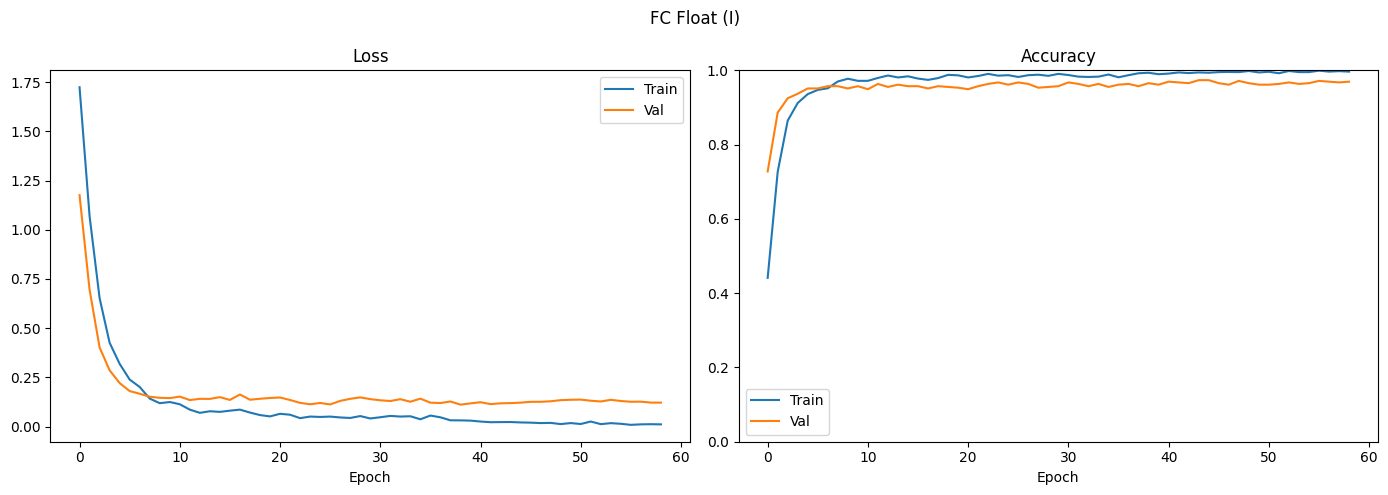

In [10]:
print('═' * 60)
print('  FC FLOAT BASELINE')
print('═' * 60)
hist_fc_float = train_model(
    model_fc_float, f'fc_float_{USE_CHANNELS}',
    fc_train_loader, fc_val_loader, DEVICE,
    epochs=150, lr=1e-3, patience=20, use_scheduler=True)
plot_history(hist_fc_float, f'FC Float ({USE_CHANNELS})')

════════════════════════════════════════════════════════════
  FC QAT W4A4
════════════════════════════════════════════════════════════
Transferring float weights to FC QAT model...
  Transferred 0/16 parameters.
[fc_qat_W4A4_I] Training: epochs=60, lr=0.0001, patience=15


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)


    1/60 tl=2.1105 vl=1.8241 ta=0.268 va=0.465 lr=1.0e-04 [0.7s]
    5/60 tl=1.1856 vl=1.0952 ta=0.778 va=0.791 lr=1.0e-04 [0.6s]
   10/60 tl=0.6227 vl=0.6672 ta=0.944 va=0.907 lr=1.0e-04 [0.6s]
   15/60 tl=0.3049 vl=0.4137 ta=0.996 va=0.945 lr=1.0e-04 [0.8s]
   20/60 tl=0.1563 vl=0.2960 ta=1.000 va=0.955 lr=1.0e-04 [0.8s]
   25/60 tl=0.0888 vl=0.2378 ta=1.000 va=0.953 lr=1.0e-04 [0.8s]
   30/60 tl=0.0564 vl=0.2081 ta=1.000 va=0.961 lr=1.0e-04 [0.6s]
   35/60 tl=0.0373 vl=0.1960 ta=1.000 va=0.951 lr=1.0e-04 [0.5s]
   40/60 tl=0.0274 vl=0.1806 ta=1.000 va=0.953 lr=1.0e-04 [0.8s]
   45/60 tl=0.0183 vl=0.1810 ta=1.000 va=0.951 lr=1.0e-04 [0.8s]
   50/60 tl=0.0146 vl=0.1688 ta=1.000 va=0.957 lr=1.0e-04 [0.5s]
   55/60 tl=0.0110 vl=0.1721 ta=1.000 va=0.953 lr=1.0e-04 [0.8s]
   60/60 tl=0.0084 vl=0.1691 ta=1.000 va=0.955 lr=1.0e-04 [0.6s]
  Restored best (val_loss=0.1681)
  Saved: 4-bits/trained_models/fc_qat_W4A4_I.pt


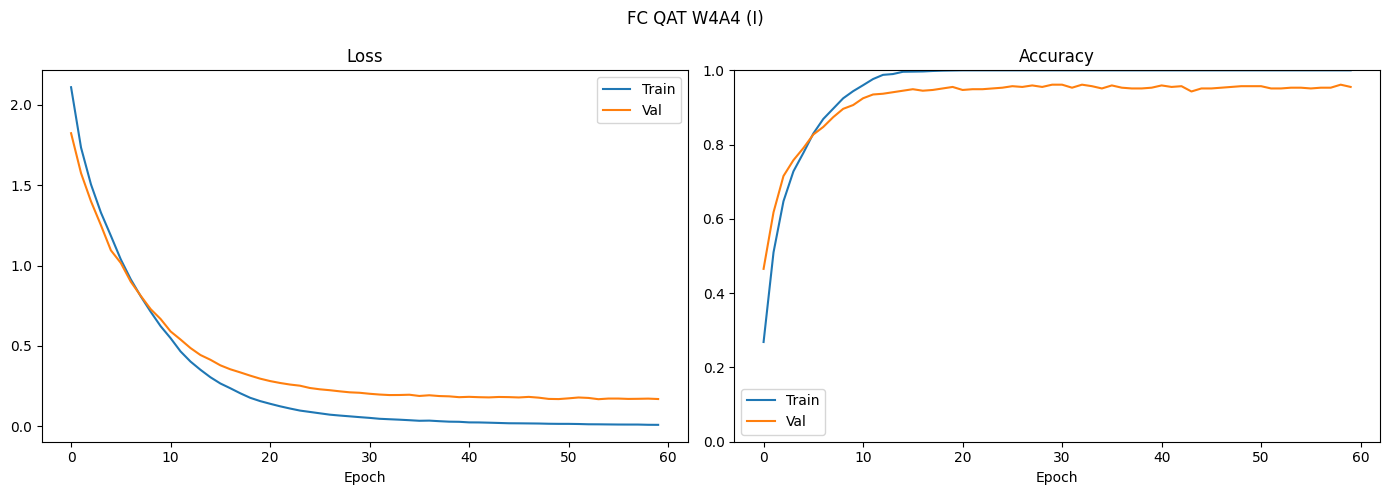

In [11]:
print('═' * 60)
print(f'  FC QAT W{FC_WEIGHT_BITS}A{FC_ACT_BITS}')
print('═' * 60)
ckpt_fc_qat = MODELS_DIR / f'fc_qat_W{FC_WEIGHT_BITS}A{FC_ACT_BITS}_{USE_CHANNELS}.pt'
if not ckpt_fc_qat.exists():
    print('Transferring float weights to FC QAT model...')
    transfer_float_weights(model_fc_float, model_fc_quant)
hist_fc_qat = train_model(
    model_fc_quant, f'fc_qat_W{FC_WEIGHT_BITS}A{FC_ACT_BITS}_{USE_CHANNELS}',
    fc_train_loader, fc_val_loader, DEVICE,
    epochs=60, lr=1e-4, patience=15, use_scheduler=False)
plot_history(hist_fc_qat, f'FC QAT W{FC_WEIGHT_BITS}A{FC_ACT_BITS} ({USE_CHANNELS})')

---
## 6. Test-Set Evaluation


  FC-Float


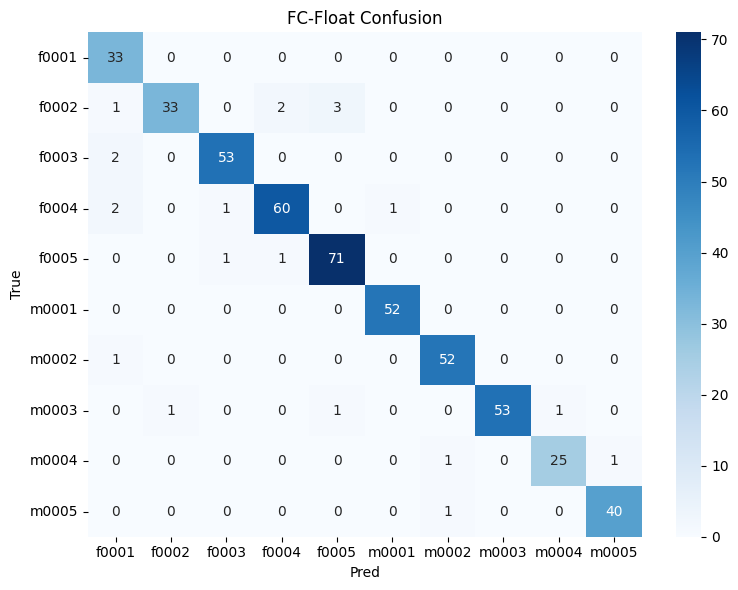

              precision    recall  f1-score   support

       f0001       0.85      1.00      0.92        33
       f0002       0.97      0.85      0.90        39
       f0003       0.96      0.96      0.96        55
       f0004       0.95      0.94      0.94        64
       f0005       0.95      0.97      0.96        73
       m0001       0.98      1.00      0.99        52
       m0002       0.96      0.98      0.97        53
       m0003       1.00      0.95      0.97        56
       m0004       0.96      0.93      0.94        27
       m0005       0.98      0.98      0.98        41

    accuracy                           0.96       493
   macro avg       0.96      0.95      0.95       493
weighted avg       0.96      0.96      0.96       493


  FC-W4A4


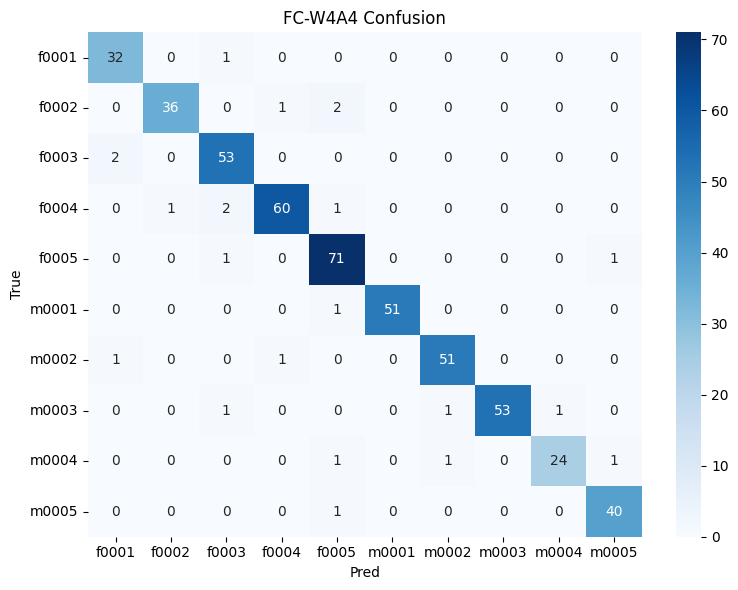

              precision    recall  f1-score   support

       f0001       0.91      0.97      0.94        33
       f0002       0.97      0.92      0.95        39
       f0003       0.91      0.96      0.94        55
       f0004       0.97      0.94      0.95        64
       f0005       0.92      0.97      0.95        73
       m0001       1.00      0.98      0.99        52
       m0002       0.96      0.96      0.96        53
       m0003       1.00      0.95      0.97        56
       m0004       0.96      0.89      0.92        27
       m0005       0.95      0.98      0.96        41

    accuracy                           0.96       493
   macro avg       0.96      0.95      0.95       493
weighted avg       0.96      0.96      0.96       493


╔════════════════════════════════════════════════════════════════════╗
║                   TRAINING & VALIDATION ACCURACY                   ║
╚════════════════════════════════════════════════════════════════════╝
───────────────────────────

In [12]:
confusion_results = {}
results = {}
eval_configs = []
eval_pairs = []

# Training and Validation evaluation
eval_configs.append(('FC-Float', model_fc_float, fc_train_loader, fc_val_loader))
eval_configs.append((f'FC-W{FC_WEIGHT_BITS}A{FC_ACT_BITS}', model_fc_quant, fc_train_loader, fc_val_loader))

# Test evaluation for confusion matrix
eval_pairs.append(('FC-Float', model_fc_float, fc_test_loader))
eval_pairs.append((f'FC-W{FC_WEIGHT_BITS}A{FC_ACT_BITS}', model_fc_quant, fc_test_loader))

# Generate confusion matrices
for name, model, loader in eval_pairs:
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    model.to(DEVICE)
    confusion_results[name] = full_eval(model, loader, DEVICE, subfolders, f'{name} Confusion')

print('\n' + '╔' + '═' * 68 + '╗')
print('║' + ' TRAINING & VALIDATION ACCURACY '.center(68) + '║')
print('╚' + '═' * 68 + '╝')

crit = nn.CrossEntropyLoss()
for name, model, train_loader, val_loader in eval_configs:
    model.to(DEVICE)
    
    _, train_acc = evaluate(model, train_loader, crit, DEVICE)
    _, val_acc = evaluate(model, val_loader, crit, DEVICE)
    
    results[name] = {'train': train_acc, 'val': val_acc}

print('─' * 70)
print(f'{"Model":<28} {"Training Accuracy":>20} {"Validation Accuracy":>20}')
print('─' * 70)
for n, accs in results.items():
    print(f'  {n:<26} {accs["train"]*100:>18.2f}% {accs["val"]*100:>22.2f}%')
print('─' * 70)

---
## 7. QONNX Export

In [13]:
def export_brevitas_qonnx(model, name, dummy_input):
    """Export Brevitas model to QONNX format for FINN."""
    p = ONNX_DIR / f'{name}.onnx'
    if p.exists():
        print(f'  [{name}] exists')
        return p
    model.eval().cpu()
    export_qonnx(model, dummy_input, str(p))
    onnx.checker.check_model(onnx.load(str(p)))
    print(f'  [{name}] exported: {p}')
    return p

qonnx_paths = {}
dummy_fc = torch.randn(1, FC_INPUT_SIZE)
qonnx_paths['fc'] = export_brevitas_qonnx(
    model_fc_quant,
    f'speaker_fc_W{FC_WEIGHT_BITS}A{FC_ACT_BITS}_{USE_CHANNELS}',
    dummy_fc)

print(f'\nExported: {list(qonnx_paths.keys())}')

  [speaker_fc_W4A4_I] exported: 4-bits/onnx_exports/speaker_fc_W4A4_I.onnx

Exported: ['fc']


## 8. Deployment artifacts for Kria KV260

In [14]:
import struct

def extract_input_scale(model, input_size_or_shape):
    """
    Extract the input QuantIdentity scale and zero_point.

    input_size_or_shape:
        - int  → FC model, flat input of that length
        - tuple (C, H, W) → CNV model, spatial input
    """
    model.eval().cpu()
    with torch.no_grad():
        if isinstance(input_size_or_shape, int):
            dummy = torch.zeros(1, input_size_or_shape)
        else:
            C, H, W = input_size_or_shape
            dummy = torch.zeros(1, C, H, W)
        qt = model.inp_quant(dummy)
        scale = qt.scale.item()
        zp    = qt.zero_point.item()
    return float(scale), float(zp)

def quantize_for_finn(X_float, scale, zero_point, bit_width, signed=True):
    """Apply the same quantization the Brevitas QuantIdentity applies.
    Returns an integer numpy array matching what the hardware sees.

    Clipping bounds are derived from bit_width using two's complement:
      Signed   n-bit → [-2^(n-1),  2^(n-1) - 1]   e.g. 4-bit: [-8,   7]
      Unsigned n-bit → [0,         2^n - 1      ]   e.g. 4-bit: [ 0,  15]

    NOTE: numpy has no native int4 dtype, so 4-bit values are stored in
    int8/uint8 containers with the correct range already applied via clipping.
    FINN reads the actual bit-width from the ONNX annotations and packs the
    hardware datapaths accordingly
    """
    x_q = np.round(X_float / scale) + zero_point
    if signed:
        q_min = -(2 ** (bit_width - 1))
        q_max =  (2 ** (bit_width - 1)) - 1
        return np.clip(x_q, q_min, q_max).astype(np.int8)
    else:
        q_min = 0
        q_max = (2 ** bit_width) - 1
        return np.clip(x_q, q_min, q_max).astype(np.uint8)

deploy_meta = {}
scale_fc, zp_fc = extract_input_scale(model_fc_quant, FC_INPUT_SIZE)
print(f'FC  input scale={scale_fc:.6f}  zero_point={zp_fc}')

# Quantize the full test set
X_test_fc_sel = select_channels(X_test, USE_CHANNELS)
X_test_fc_flat = X_test_fc_sel.reshape(X_test_fc_sel.shape[0], -1)
X_test_fc_q = quantize_for_finn(
    X_test_fc_flat, scale_fc, zp_fc,
    bit_width=FC_ACT_BITS,
    signed=True
)

fc_deploy = FINN_BUILD_DIR / 'fc' / 'deploy_extras'
fc_deploy.mkdir(parents=True, exist_ok=True)
np.save(fc_deploy / 'X_test_q.npy',    X_test_fc_q)
np.save(fc_deploy / 'y_test.npy',      y_test)
np.save(fc_deploy / 'input_scale.npy', np.array([scale_fc, zp_fc], dtype=np.float32))
with open(fc_deploy / 'classes.json', 'w') as f:
    json.dump({'classes': subfolders, 'num_classes': NUM_CLASSES,
               'use_channels': USE_CHANNELS, 'n_mfcc': N_MFCC,
               'mfcc_frames': MFCC_FRAMES, 'hop_length': HOP_LENGTH,
               'n_fft': 2048, 'sampling_freq': SAMPLING_FREQ,
               'input_shape_fc': [1, int(FC_INPUT_SIZE)],
               'input_shape_cnv': [1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES],
               'weight_bits': FC_WEIGHT_BITS,
               'act_bits': FC_ACT_BITS,
               'hidden_act_bits':  FC_HIDDEN_BITS},
               f, indent=2)
deploy_meta['fc'] = str(fc_deploy)
print(f'FC  deploy extras → {fc_deploy}')
print(f'    X_test_q shape : {X_test_fc_q.shape}  dtype={X_test_fc_q.dtype}')

print('\nDeployment artifacts saved.')

FC  input scale=0.718513  zero_point=0.0
FC  deploy extras → 4-bits/finn_build/fc/deploy_extras
    X_test_q shape : (493, 1280)  dtype=int8

Deployment artifacts saved.


---
## 9. FINN Synthesis


### Build Configuration

In [15]:
# ─── Source Vitis HLS ─────────────────────────────────────────────────────────
vitis_settings = '/tools/Xilinx/Vitis_HLS/2022.2/settings64.sh'
if os.path.exists(vitis_settings):
    result = subprocess.run(
        ['bash', '-c', f'source {vitis_settings} && env'],
        capture_output=True, text=True)
    for line in result.stdout.splitlines():
        if '=' in line:
            k, _, v = line.partition('=')
            os.environ[k] = v
    print(f'vitis_hls: {subprocess.run(["which","vitis_hls"], capture_output=True, text=True).stdout.strip()}')
else:
    print(f'WARNING: {vitis_settings} not found')

os.environ['VIVADO_PATH'] = '/tools/Xilinx/Vivado/2022.2'
os.environ['HLS_PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2'
os.environ['XILINX_LOCAL_USER_DATA'] = 'no'

vitis_hls: /tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls


In [16]:
# ─── FINN build config ────────────────────────────────────────────────────────
import finn.builder.build_dataflow as build
import finn.builder.build_dataflow_config as build_cfg
from finn.builder.build_dataflow_config import DataflowBuildConfig, ShellFlowType
from finn.builder.build_dataflow_steps import (
    step_qonnx_to_finn, step_tidy_up, step_streamline, step_convert_to_hw,
    step_create_dataflow_partition, step_specialize_layers,
    step_target_fps_parallelization, step_apply_folding_config,
    step_minimize_bit_width, step_generate_estimate_reports,
    step_hw_codegen, step_hw_ipgen, step_set_fifo_depths,
    step_create_stitched_ip, step_measure_rtlsim_performance,
    step_synthesize_bitfile, step_make_pynq_driver, step_deployment_package
)

# Build steps
BUILD_STEPS = [
    step_qonnx_to_finn,              
    step_tidy_up,                    
    step_streamline,                 
    step_convert_to_hw,              
    step_create_dataflow_partition,  
    step_specialize_layers,          
    step_target_fps_parallelization, 
    step_apply_folding_config,       
    step_minimize_bit_width,         
    step_generate_estimate_reports,  
    step_hw_codegen,                 
    step_hw_ipgen,                   
    step_set_fifo_depths,            
    step_create_stitched_ip,         
    step_measure_rtlsim_performance, 
    step_synthesize_bitfile,         
    step_make_pynq_driver,           
    step_deployment_package,         
]
print(f'FINN: {len(BUILD_STEPS)} steps | Build for FPGA part: {FPGA_PART} running @ {1000/CLOCK_NS:.0f} MHz')

FINN: 18 steps | Build for FPGA part: xck26-sfvc784-2LV-c running @ 200 MHz


### Running Synthesis

In [17]:
# ─── Run synthesis ────────────────────────────────────────────────────────────
for tag, onnx_path in qonnx_paths.items():
    bd = FINN_BUILD_DIR / tag
    if (bd/'bitfile').exists() and any((bd/'bitfile').glob('*.bit')):
        print(f'[{tag}] Bitstream exists — skip.')
        continue
    label = tag.upper()
    print(f'\n{"="*60}')
    print(f'  FINN Build: {label} | VIVADO_ZYNQ |')
    print(f'{"="*60}\n')
    cfg = DataflowBuildConfig(
        output_dir=str(bd),
        synth_clk_period_ns=CLOCK_NS,
        fpga_part=FPGA_PART,
        target_fps=TARGET_FPS,
        board=BOARD,
        shell_flow_type=ShellFlowType.VIVADO_ZYNQ,
        hls_clk_period_ns=CLOCK_NS,
        # ── RTL simulation settings ──────────────────────────────────────
        # 100 samples is enough to confirm the dataflow is not deadlocked
        # and to get a stable throughput estimate. Keep it small to avoid
        # multi-hour RTL sim runs before you know the design works.
        rtlsim_batch_size=100,
        # ─────────────────────────────────────────────────────────────────
        generate_outputs=[
            build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
            build_cfg.DataflowOutputType.STITCHED_IP,
            build_cfg.DataflowOutputType.RTLSIM_PERFORMANCE,
            build_cfg.DataflowOutputType.BITFILE,
            build_cfg.DataflowOutputType.PYNQ_DRIVER,
            build_cfg.DataflowOutputType.DEPLOYMENT_PACKAGE,
        ],
        steps=BUILD_STEPS,
        save_intermediate_models=True,
    )
    t0 = time.time()
    build.build_dataflow_cfg(str(onnx_path), cfg)
    print(f'\n[{tag}] Done in {(time.time()-t0)/60:.1f} min.')


  FINN Build: FC | VIVADO_ZYNQ |

Building dataflow accelerator from 4-bits/onnx_exports/speaker_fc_W4A4_I.onnx
Intermediate outputs will be generated in /tmp/finn_dev_emanuel-hernandez
Final outputs will be generated in 4-bits/finn_build/fc
Build log is at 4-bits/finn_build/fc/build_dataflow.log
Running step: step_qonnx_to_finn [1/18]
Running step: step_tidy_up [2/18]
Running step: step_streamline [3/18]
Running step: step_convert_to_hw [4/18]
Running step: step_create_dataflow_partition [5/18]
Running step: step_specialize_layers [6/18]
Running step: step_target_fps_parallelization [7/18]
Running step: step_apply_folding_config [8/18]
Running step: step_minimize_bit_width [9/18]
Running step: step_generate_estimate_reports [10/18]
Running step: step_hw_codegen [11/18]
Running step: step_hw_ipgen [12/18]
Running step: step_set_fifo_depths [13/18]
Running step: step_create_stitched_ip [14/18]
Running step: step_measure_rtlsim_performance [15/18]
Running step: step_synthesize_bitfile [

---
## 10. Post-Synthesis Reports

In [18]:
import re

KV260_RESOURCES = {
    'LUT': 117120, 'FF': 234240, 'BRAM_36K': 144, 'URAM': 64, 'DSP': 1248,
}

def parse_post_synth_resources(build_dir):
    json_path = build_dir / 'report' / 'post_synth_resources.json'
    if not json_path.exists(): return None, None
    with open(json_path) as f: data = json.load(f)
    top = data.get('(top)', {})
    res = {
        'LUT': top.get('LUT', 0), 'SRL': top.get('SRL', 0),
        'FF': top.get('FF', 0), 'BRAM_36K': top.get('BRAM_36K', 0),
        'BRAM_18K': top.get('BRAM_18K', 0), 'URAM': top.get('URAM', 0),
        'DSP': top.get('DSP', 0),
    }
    res['BRAM_36K_equiv'] = res['BRAM_36K'] + res['BRAM_18K'] / 2.0
    return res, str(json_path)

def parse_post_route_timing(build_dir):
    rpt_path = build_dir / 'report' / 'post_route_timing.rpt'
    if not rpt_path.exists(): return None, None
    with open(rpt_path) as f: text = f.read()
    timing = {}
    m = re.search(r'clk_pl_0\s+\{[^}]+\}\s+([\d.]+)\s+([\d.]+)', text)
    if m:
        timing['period_ns'] = float(m.group(1))
        timing['target_freq_MHz'] = float(m.group(2))
    m_wns = re.search(r'Clock\s+WNS\(ns\).*?\n\s*clk_pl_0\s+([-\d.]+)', text, re.DOTALL)
    if m_wns:
        timing['WNS_ns'] = float(m_wns.group(1))
    if 'period_ns' in timing and 'WNS_ns' in timing:
        timing['max_freq_MHz'] = 1000.0 / (timing['period_ns'] - timing['WNS_ns'])
        timing['timing_met'] = timing['WNS_ns'] >= 0
    return timing, str(rpt_path)

# Collect and display
for tag in qonnx_paths:
    bd = FINN_BUILD_DIR / tag
    if not bd.exists():
        print(f'[{tag}] Build dir not found — skipping.')
        continue
    res, res_path = parse_post_synth_resources(bd)
    tim, tim_path = parse_post_route_timing(bd)
    if res is None and tim is None:
        print(f'[{tag}] No reports found.')
        continue
    label = tag.upper()
    print(f'\n╔{"═"*60}╗')
    print(f'║ {label:^58} ║')
    print(f'╚{"═"*60}╝')
    if res:
        print(f'  {"Resource":<22} {"Used":>10} {"Available":>12} {"Util":>10}')
        print(f'  {"─"*56}')
        for rname, rkey, avail_key in [
            ('LUT', 'LUT', 'LUT'), ('FF', 'FF', 'FF'),
            ('BRAM (36K-eq)', 'BRAM_36K_equiv', 'BRAM_36K'),
            ('DSP', 'DSP', 'DSP'), ('URAM', 'URAM', 'URAM')]:
            v = res.get(rkey, 0)
            a = KV260_RESOURCES[avail_key]
            v_str = f'{v:,.0f}' if v == int(v) else f'{v:,.1f}'
            print(f'  {rname:<22} {v_str:>10} {a:>12,} {v/a*100:>8.1f} %')
    if tim:
        print(f'\n  WNS: {tim.get("WNS_ns","?"):.3f} ns  |  Max freq: {tim.get("max_freq_MHz","?"):.1f} MHz  |  Timing Met: {tim.get("timing_met","?")}')


╔════════════════════════════════════════════════════════════╗
║                             FC                             ║
╚════════════════════════════════════════════════════════════╝
  Resource                     Used    Available       Util
  ────────────────────────────────────────────────────────
  LUT                        11,767      117,120     10.0 %
  FF                         20,828      234,240      8.9 %
  BRAM (36K-eq)                30.5          144     21.2 %
  DSP                            13        1,248      1.0 %
  URAM                            0           64      0.0 %

  WNS: 0.206 ns  |  Max freq: 208.6 MHz  |  Timing Met: True


### RTL Simulation Report

In [19]:
# ─── RTL Simulation Performance Report ───────────────────────────────────────
# Reads finn_build_v2/{tag}/report/rtlsim_performance.json produced by step_measure_rtlsim_performance.

print('\n' + '═' * 60)
print('  RTL SIMULATION PERFORMANCE REPORT')
print('═' * 60)

for tag in qonnx_paths:
    bd = FINN_BUILD_DIR / tag
    rtlsim_path = bd / 'report' / 'rtlsim_performance.json'

    print(f'\n  ┌─ {tag.upper()} ─────────────────────────────────')

    if not rtlsim_path.exists():
        print(f'  │  ✗ REPORT NOT FOUND: {rtlsim_path}')
        print(f'  │    This means the RTL simulation either:')
        print(f'  │    - deadlocked (never produced output), or')
        print(f'  │    - was skipped because a prior step failed.')
        print(f'  │    Check finn_build_v2/{tag}/build.log for timeout/hang.')
        print(f'  └─────────────────────────────────────────────')
        continue

    with open(rtlsim_path) as f:
        rdata = json.load(f)

    throughput = rdata.get('throughput[images/s]', None)
    runtime_ms = rdata.get('runtime[ms]', None)
    n_samples  = rdata.get('N', None)

    print(f'  │  Samples  : {n_samples}')
    print(f'  │  Throughput: {float(throughput):>12,.1f} images/s' if throughput else '  │  Throughput: N/A')
    print(f'  │  Runtime  : {float(runtime_ms):>12,.1f} ms'        if runtime_ms else '  │  Runtime  : N/A')
    print(f'  │  File     : {rtlsim_path}')
    print(f'  └─────────────────────────────────────────────')

print()


════════════════════════════════════════════════════════════
  RTL SIMULATION PERFORMANCE REPORT
════════════════════════════════════════════════════════════

  ┌─ FC ─────────────────────────────────
  │  Samples  : 100
  │  Throughput:     12,135.5 images/s
  │  Runtime  :          8.2 ms
  │  File     : 4-bits/finn_build/fc/report/rtlsim_performance.json
  └─────────────────────────────────────────────

